In [5]:
#Arshit Samkria - 24BCE10444 :)
#Simran Kumari - 24BDS1031 XD 

import pandas as pd
import numpy as np
import boto3
from datetime import datetime, timedelta

BUCKET_NAME = "arshit-p3-demand-forecast-aws"

np.random.seed(42)

products = [f"PROD-{i:02d}" for i in range(1, 21)]
stores = ["STORE-01", "STORE-02", "STORE-03"]
start_date = datetime(2024, 1, 1)
num_days = 730

product_base_demand = {}  # NEW LINE

rows = []
for product in products:
    base_demand = np.random.randint(20, 100)
    product_base_demand[product] = base_demand  # NEW LINE
    for store in stores:
        for day_offset in range(num_days):
            date = start_date + timedelta(days=day_offset)
            day_of_year = date.timetuple().tm_yday

            seasonal = 1 + 0.4 * np.sin(2 * np.pi * day_of_year / 365)
            weekend_boost = 1.2 if date.weekday() >= 5 else 1.0
            promo_flag = 1 if np.random.rand() < 0.05 else 0
            promo_boost = 1.4 if promo_flag else 1.0
            noise = np.random.normal(1, 0.1)

            units_sold = max(0, int(base_demand * seasonal * weekend_boost * promo_boost * noise))
            price = round(np.random.uniform(5, 50), 2)

            rows.append([date.strftime("%Y-%m-%d"), store, product, units_sold, price, promo_flag])

df = pd.DataFrame(rows, columns=["date", "store_id", "product_id", "units_sold", "price", "promo_flag"])

df.to_csv("sales_data.csv", index=False)
print("Saved locally. Rows:", len(df))
print(df.head())

s3 = boto3.client("s3")
s3.upload_file("sales_data.csv", BUCKET_NAME, "raw/sales_data.csv")
print("Uploaded to S3 successfully!")


Saved locally. Rows: 43800
         date  store_id product_id  units_sold  price  promo_flag
0  2024-01-01  STORE-01    PROD-01          76  12.02           0
1  2024-01-02  STORE-01    PROD-01          82   7.61           0
2  2024-01-03  STORE-01    PROD-01          83   5.93           0
3  2024-01-04  STORE-01    PROD-01          78  42.46           0
4  2024-01-05  STORE-01    PROD-01          70  18.69           0
Uploaded to S3 successfully!


In [6]:
demands = list(product_base_demand.values())
q1, q2, q3 = np.percentile(demands, [25, 50, 75])

def get_category(product):
    d = product_base_demand[product]
    if d <= q1: return 0
    elif d <= q2: return 1
    elif d <= q3: return 2
    else: return 3

product_category = {p: get_category(p) for p in products}
print(product_category)

{'PROD-01': 2, 'PROD-02': 0, 'PROD-03': 0, 'PROD-04': 1, 'PROD-05': 3, 'PROD-06': 3, 'PROD-07': 0, 'PROD-08': 2, 'PROD-09': 0, 'PROD-10': 2, 'PROD-11': 2, 'PROD-12': 1, 'PROD-13': 1, 'PROD-14': 0, 'PROD-15': 3, 'PROD-16': 1, 'PROD-17': 2, 'PROD-18': 3, 'PROD-19': 3, 'PROD-20': 1}


In [7]:
import json

BUCKET_NAME = "arshit-p3-demand-forecast-aws"
prediction_length = 14

train_data = []
test_data = []
transform_data = []  # <-- NEW: Specifically for batch transform (includes future covariates)

for (product, store), group in df.groupby(["product_id", "store_id"]):
    group = group.sort_values("date")
    values = group["units_sold"].tolist()
    promo_features = group["promo_flag"].tolist()
    start = group["date"].iloc[0]
    cat = [product_category[product]]  # NEW LINE

    # TRAIN SET: Drop last 14 days from both target AND covariates
    train_data.append({
        "start": start,
        "target": values[:-prediction_length],
        "dynamic_feat": [promo_features[:-prediction_length]],
        "cat": cat
    })

    # TEST SET: Full series + full covariate length (for MAPE calculation)
    test_data.append({
        "start": start,
        "target": values,
        "dynamic_feat": [promo_features],
        "cat": cat
    })

    # TRANSFORM SET: Historical data + FUTURE covariates (for Batch Transform)
    # IMPORTANT: DeepAR needs dynamic_feat for the ENTIRE prediction range.
    # Since we don't have real future promo data, we'll extend with zeros
    # (In production, you would use actual planned promotion data)
    future_promo = [0] * prediction_length  # assume no promotions during forecast
    full_promo_features = promo_features + future_promo
    
    transform_data.append({
        "start": start,
        "target": values,  # Full historical target
        "dynamic_feat": [full_promo_features],  # Historical + future covariate values
        "cat": cat
    })

def write_jsonlines(data, filename):
    with open(filename, "w") as f:
        for entry in data:
            f.write(json.dumps(entry) + "\n")

write_jsonlines(train_data, "train.json")
write_jsonlines(test_data, "test.json")
write_jsonlines(transform_data, "transform.json")  # <-- NEW

s3.upload_file("train.json", BUCKET_NAME, "processed/train.json")
s3.upload_file("test.json", BUCKET_NAME, "processed/test.json")
s3.upload_file("transform.json", BUCKET_NAME, "processed/transform.json")  # <-- NEW

print("Train/test/transform files created with dynamic_feat (promo_flag).")
print("Number of series:", len(train_data))

Train/test/transform files created with dynamic_feat (promo_flag).
Number of series: 60


In [8]:
import sagemaker
from sagemaker import image_uris

role = sagemaker.get_execution_role()
session = sagemaker.Session()
region = session.boto_region_name

image_uri = image_uris.retrieve("forecasting-deepar", region)

s3_train = f"s3://{BUCKET_NAME}/processed/train.json"
s3_test = f"s3://{BUCKET_NAME}/processed/test.json"
s3_output = f"s3://{BUCKET_NAME}/models/"

estimator = sagemaker.estimator.Estimator(
    image_uri=image_uri,
    role=role,
    instance_count=1,
    instance_type="ml.c5.xlarge",
    output_path=s3_output,
    sagemaker_session=session,
)

estimator.set_hyperparameters(
    time_freq="D",
    context_length="30",
    prediction_length=str(prediction_length),
    epochs="20",
    num_cells="40",
    num_layers="2",
    likelihood="gaussian",
    num_dynamic_feat="1",
    cardinality="4"
)

estimator.fit({"train": s3_train, "test": s3_test})

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


INFO:sagemaker:Creating training-job with name: forecasting-deepar-2026-07-12-09-01-49-917


2026-07-12 09:01:51 Starting - Starting the training job...
2026-07-12 09:02:06 Starting - Preparing the instances for training...
2026-07-12 09:02:47 Downloading - Downloading the training image..............Docker entrypoint called with argument(s): train
Running default environment configuration script
Running custom environment configuration script
/opt/amazon/lib/python3.9/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
[07/12/2026 09:05:05 INFO 139864751380288] Reading default configuration from /opt/amazon/lib/python3.9/site-packages/algorithm/resources/default-input.json: {'_kvstore': 'auto', '_num_gpus': 'auto', '_num_kv_servers': 'auto', '_tuning_objective_metric': '', 'cardinality': 'auto', 'dropout_rate': '0.10', 'early_stopping_patience': '', 'embedding_dimension': '10', 'learning_rate': '0.001', 'likelihood': 'student-t', 'mini_batch_size': '128', 'num_cells': '40', 'num_dynamic_feat':

In [9]:
from sagemaker.inputs import BatchDataCaptureConfig

transformer = estimator.transformer(
    instance_count=1,
    instance_type="ml.m5.xlarge",
    output_path=f"s3://{BUCKET_NAME}/forecasts/",
    strategy="SingleRecord",
    assemble_with="Line",
    accept="application/jsonlines",
)

# Pass batch_data_capture_config to .transform(), not to .transformer()
transformer.transform(
    data=f"s3://{BUCKET_NAME}/processed/transform.json",  # Changed from train.json
    content_type="application/jsonlines",
    split_type="Line",
    batch_data_capture_config=BatchDataCaptureConfig(
        destination_s3_uri=f"s3://{BUCKET_NAME}/captured-data/",
        generate_inference_id=True
    )
)

transformer.wait()
print("Batch transform complete. Data captured in S3 for Model Monitor.")

INFO:sagemaker:Creating model with name: forecasting-deepar-2026-07-12-09-11-07-237
INFO:sagemaker:Creating transform job with name: forecasting-deepar-2026-07-12-09-11-07-875


..............................
.2026-07-12T09:16:14.568:[sagemaker logs]: MaxConcurrentTransforms=4, MaxPayloadInMB=6, BatchStrategy=SINGLE_RECORD
Docker entrypoint called with argument(s): serve
Running default environment configuration script
Running custom environment configuration script
/opt/amazon/lib/python3.9/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
Failed to set debug level to 20, using INFO
[07/12/2026 09:16:13 INFO 139646131078976] Estimated memory required per model 11.665892601013184MB.
[07/12/2026 09:16:13 INFO 139646131078976] Estimated available memory 14445.910402297974MB.
Docker entrypoint called with argument(s): serve
Running default environment configuration script
Running custom environment configuration script
/opt/amazon/lib/python3.9/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:


In [10]:
import boto3
import json

s3 = boto3.client("s3")

# download the forecast output file
local_output = "forecast_output.jsonl"
s3.download_file(BUCKET_NAME, "forecasts/transform.json.out", local_output)  # <-- CHANGED: train -> transform

with open(local_output, "r") as f:
    forecast_lines = [json.loads(line) for line in f]

with open("test.json", "r") as f:
    actual_lines = [json.loads(line) for line in f]

# compare forecasted median (0.5 quantile) vs actual for the last 14 days of each series
mape_scores = []
for i, (forecast, actual) in enumerate(zip(forecast_lines, actual_lines)):
    predicted_median = forecast["quantiles"]["0.5"]  # This will now work because the transform succeeded
    actual_last_14 = actual["target"][-prediction_length:]
    
    errors = [abs(a - p) / a for a, p in zip(actual_last_14, predicted_median) if a != 0]
    if errors:
        mape = sum(errors) / len(errors) * 100
        mape_scores.append(mape)

overall_mape = sum(mape_scores) / len(mape_scores)
print(f"Average MAPE across all products: {overall_mape:.2f}%")
print(f"Number of product-store series evaluated: {len(mape_scores)}")

Average MAPE across all products: 13.31%
Number of product-store series evaluated: 60


In [11]:
cloudwatch = boto3.client("cloudwatch", region_name=region)

cloudwatch.put_metric_data(
    Namespace="P3-DemandForecasting",
    MetricData=[
        {
            "MetricName": "MAPE",
            "Value": overall_mape,
            "Unit": "Percent",
        }
    ]
)

print(f"Pushed MAPE of {overall_mape:.2f}% to CloudWatch under namespace P3-DemandForecasting") 
cloudwatch.put_metric_alarm(
    AlarmName="P3-MAPE-High-Alarm",
    ComparisonOperator="GreaterThanThreshold",
    EvaluationPeriods=1,
    MetricName="MAPE",
    Namespace="P3-DemandForecasting",
    Period=300,
    Statistic="Average",
    Threshold=15.0,          # alert if MAPE > 15%
    ActionsEnabled=False,    # set to True in production
    AlarmDescription="Alert if forecast MAPE exceeds 15%"
)
print("CloudWatch Alarm configured to flag MAPE > 15%.")

Pushed MAPE of 13.31% to CloudWatch under namespace P3-DemandForecasting
CloudWatch Alarm configured to flag MAPE > 15%.


In [12]:
from datetime import datetime, timedelta

response = cloudwatch.get_metric_statistics(
    Namespace="P3-DemandForecasting",
    MetricName="MAPE",
    StartTime=datetime.utcnow() - timedelta(hours=1),
    EndTime=datetime.utcnow() + timedelta(minutes=5),
    Period=300,
    Statistics=["Average"],
)

print(response["Datapoints"])

[{'Timestamp': datetime.datetime(2026, 7, 12, 9, 18, tzinfo=tzlocal()), 'Average': 13.310268584887819, 'Unit': 'Percent'}]


In [13]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (118 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pillow-12.3.0-cp310-cp310-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x

INFO:matplotlib.font_manager:Failed to extract font properties from /usr/share/fonts/cantarell/Cantarell-VF.otf: Can not load face (SFNT font table missing; error code 0x8e)
INFO:matplotlib.font_manager:generated new fontManager


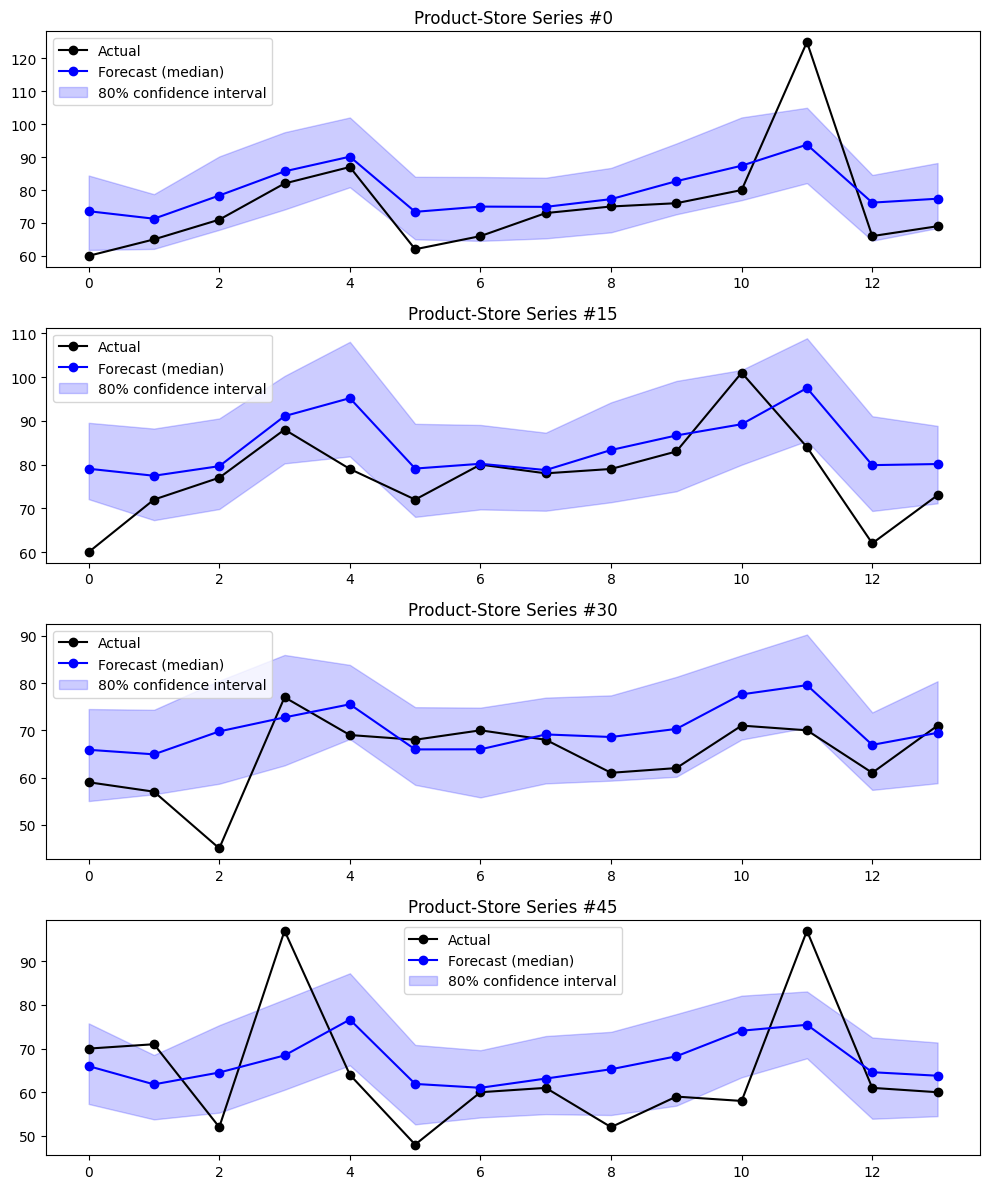

Chart saved as forecast_vs_actual.png


In [14]:
import matplotlib.pyplot as plt

# pick a few products to visualize
sample_indices = [0, 15, 30, 45]

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(10, 12))

for ax, idx in zip(axes, sample_indices):
    forecast = forecast_lines[idx]
    actual = actual_lines[idx]

    predicted_median = forecast["quantiles"]["0.5"]
    predicted_lower = forecast["quantiles"]["0.1"]
    predicted_upper = forecast["quantiles"]["0.9"]
    actual_last_14 = actual["target"][-prediction_length:]

    days = range(prediction_length)
    ax.plot(days, actual_last_14, label="Actual", marker="o", color="black")
    ax.plot(days, predicted_median, label="Forecast (median)", marker="o", color="blue")
    ax.fill_between(days, predicted_lower, predicted_upper, color="blue", alpha=0.2, label="80% confidence interval")
    ax.set_title(f"Product-Store Series #{idx}")
    ax.legend()

plt.tight_layout()
plt.savefig("forecast_vs_actual.png", dpi=150)
plt.show()
print("Chart saved as forecast_vs_actual.png")

In [15]:
from sagemaker.model_monitor import DefaultModelMonitor, BatchTransformInput, CronExpressionGenerator
from sagemaker.model_monitor.dataset_format import DatasetFormat, MonitoringDatasetFormat

my_monitor = DefaultModelMonitor(
    role=role,
    instance_count=1,
    instance_type="ml.m5.xlarge",
    volume_size_in_gb=20,
    max_runtime_in_seconds=1800,
)

baseline_uri = f"s3://{BUCKET_NAME}/processed/train.json"

my_monitor.suggest_baseline(
    baseline_dataset=baseline_uri,
    dataset_format=DatasetFormat.json(lines=True),
    output_s3_uri=f"s3://{BUCKET_NAME}/monitoring/baseline/",
    wait=True,
    logs=True,
)

INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.
INFO:sagemaker:Creating processing-job with name baseline-suggestion-job-2026-07-12-09-26-56-568


...................2026-07-12 09:30:04.571652: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-07-12 09:30:04.571698: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2026-07-12 09:30:06.049532: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-07-12 09:30:06.049568: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-07-12 09:30:06.049590: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (ip-10-0-70-179.ec2.internal): /proc/driver/nvidia/version does not exist
2026-07-12 09:30:06.049964: I 

In [19]:
batch_transform_input = BatchTransformInput(
    data_captured_destination_s3_uri=f"s3://{BUCKET_NAME}/captured-data/",
    destination="/opt/ml/processing/input/monitoring_data",
    dataset_format=MonitoringDatasetFormat.json(lines=True),
)

my_monitor.create_monitoring_schedule(
    monitor_schedule_name="p3-forecast-datadrift-monitor",
    batch_transform_input=batch_transform_input,
    output_s3_uri=f"s3://{BUCKET_NAME}/monitoring/reports/",
    schedule_cron_expression=CronExpressionGenerator.daily(hour=8),
    enable_cloudwatch_metrics=True,
)
print("Monitoring schedule created:", my_monitor.monitoring_schedule_name)

INFO:sagemaker.model_monitor.model_monitoring:Creating Monitoring Schedule with name: p3-forecast-datadrift-monitor
ERROR:sagemaker.model_monitor.model_monitoring:Failed to create monitoring schedule.
Traceback (most recent call last):
  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model_monitor/model_monitoring.py", line 2050, in create_monitoring_schedule
    self._create_monitoring_schedule_from_job_definition(
  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model_monitor/model_monitoring.py", line 1594, in _create_monitoring_schedule_from_job_definition
    self.sagemaker_session.sagemaker_client.create_monitoring_schedule(
  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py", line 606, in _api_call
    return self._make_api_call(operation_name, kwargs)
  File "/home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/context.py", line 123, in wrapp

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:7                                                                                    │
│                                                                                                  │
│    4 │   dataset_format=MonitoringDatasetFormat.json(lines=True),                                │
│    5 )                                                                                           │
│    6                                                                                             │
│ ❱  7 my_monitor.create_monitoring_schedule(                                                      │
│    8 │   monitor_schedule_name="p3-forecast-datadrift-monitor",                                  │
│    9 │   batch_transform_input=batch_transform_input,                                            │
│   10 │   output_s3_uri=f"s3://{BUCKET_NAME}/monitoring/reports/",                                │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model_monitor/model │
│ _monitoring.py:2050 in create_monitoring_schedule                                                │
│                                                                                                  │
│   2047 │   │                                                                                     │
│   2048 │   │   # create schedule                                                                 │
│   2049 │   │   try:                                                                              │
│ ❱ 2050 │   │   │   self._create_monitoring_schedule_from_job_definition(                         │
│   2051 │   │   │   │   monitor_schedule_name=monitor_schedule_name,                              │
│   2052 │   │   │   │   job_definition_name=new_job_definition_name,                              │
│   2053 │   │   │   │   schedule_cron_expression=schedule_cron_expression,                        │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/sagemaker/model_monitor/model │
│ _monitoring.py:1594 in _create_monitoring_schedule_from_job_definition                           │
│                                                                                                  │
│   1591 │   │   # config key MONITORING_SCHEDULE_INTER_CONTAINER_ENCRYPTION_PATH here             │
│   1592 │   │   # because no MonitoringJobDefinition is set for this call                         │
│   1593 │   │                                                                                     │
│ ❱ 1594 │   │   self.sagemaker_session.sagemaker_client.create_monitoring_schedule(               │
│   1595 │   │   │   MonitoringScheduleName=monitor_schedule_name,                                 │
│   1596 │   │   │   MonitoringScheduleConfig=monitoring_schedule_config,                          │
│   1597 │   │   │   Tags=all_tags or [],                                                          │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:606 in     │
│ _api_call                                                                                        │
│                                                                                                  │
│    603 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    604 │   │   │   │   )                                                                         │
│    605 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  606 │   │   │   return self._make_api_call(operation_nam

In [20]:
%%writefile lambda_function.py
import json
import boto3

def lambda_handler(event, context):
    s3 = boto3.client("s3")
    bucket = event["bucket"]
    prediction_length = event.get("prediction_length", 14)

    forecast_obj = s3.get_object(Bucket=bucket, Key=event["forecast_key"])
    forecast_lines = [json.loads(l) for l in forecast_obj["Body"].read().decode("utf-8").splitlines()]

    actual_obj = s3.get_object(Bucket=bucket, Key=event["actual_key"])
    actual_lines = [json.loads(l) for l in actual_obj["Body"].read().decode("utf-8").splitlines()]

    mape_scores = []
    for forecast, actual in zip(forecast_lines, actual_lines):
        predicted_median = forecast["quantiles"]["0.5"]
        actual_last = actual["target"][-prediction_length:]
        errors = [abs(a - p) / a for a, p in zip(actual_last, predicted_median) if a != 0]
        if errors:
            mape_scores.append(sum(errors) / len(errors) * 100)

    overall_mape = sum(mape_scores) / len(mape_scores) if mape_scores else 0.0

    boto3.client("cloudwatch").put_metric_data(
        Namespace="P3-DemandForecasting",
        MetricData=[{"MetricName": "MAPE", "Value": overall_mape, "Unit": "Percent"}]
    )
    return {"overall_mape": overall_mape, "series_evaluated": len(mape_scores)}

Overwriting lambda_function.py


In [21]:
import boto3, zipfile, io

account_id = boto3.client("sts").get_caller_identity()["Account"]
lab_role_arn = f"arn:aws:iam::{account_id}:role/LabRole"

lambda_client = boto3.client("lambda", region_name=region)

zip_buffer = io.BytesIO()
with zipfile.ZipFile(zip_buffer, "w") as z:
    z.write("lambda_function.py")
zip_buffer.seek(0)

lambda_client.create_function(
    FunctionName="p3-mape-calculator",
    Runtime="python3.12",
    Role=lab_role_arn,
    Handler="lambda_function.lambda_handler",
    Code={"ZipFile": zip_buffer.read()},
    Timeout=60,
    MemorySize=256,
)
print("Lambda deployed.")

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:13                                                                                   │
│                                                                                                  │
│   10 │   z.write("lambda_function.py")                                                           │
│   11 zip_buffer.seek(0)                                                                          │
│   12                                                                                             │
│ ❱ 13 lambda_client.create_function(                                                              │
│   14 │   FunctionName="p3-mape-calculator",                                                      │
│   15 │   Runtime="python3.12",                                                                   │
│   16 │   Role=lab_role_arn,                                                                      │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:606 in     │
│ _api_call                                                                                        │
│                                                                                                  │
│    603 │   │   │   │   │   f"{py_operation_name}() only accepts keyword arguments."              │
│    604 │   │   │   │   )                                                                         │
│    605 │   │   │   # The "self" in this scope is referring to the BaseClient.                    │
│ ❱  606 │   │   │   return self._make_api_call(operation_name, kwargs)                            │
│    607 │   │                                                                                     │
│    608 │   │   _api_call.__name__ = str(py_operation_name)                                       │
│    609                                                                                           │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/context.py:123 in    │
│ wrapper                                                                                          │
│                                                                                                  │
│   120 │   │   │   with start_as_current_context():                                               │
│   121 │   │   │   │   if hook:                                                                   │
│   122 │   │   │   │   │   hook()                                                                 │
│ ❱ 123 │   │   │   │   return func(*args, **kwargs)                                               │
│   124 │   │                                                                                      │
│   125 │   │   return wrapper                                                                     │
│   126                                                                                            │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.10/site-packages/botocore/client.py:1094 in    │
│ _make_api_call                                                                                   │
│                                                                                                  │
│   1091 │   │   │   │   'error_code_override'                                                     │
│   1092 │   │   │   ) or error_info.get("Code")                                                   │
│   1093 │   │   │   error_class = self.exceptions.from_code(error_code)                           │
│ ❱ 1094 │   │   │   raise error_class(parsed_response, opera

In [22]:
import json

state_machine_definition = {
  "Comment": "P3 Demand Forecasting Retraining Pipeline",
  "StartAt": "TrainDeepAR",
  "States": {
    "TrainDeepAR": {
      "Type": "Task",
      "Resource": "arn:aws:states:::sagemaker:createTrainingJob.sync",
      "Parameters": {
        "TrainingJobName.$": "States.Format('p3-deepar-retrain-{}', $$.Execution.Name)",
        "RoleArn": lab_role_arn,
        "AlgorithmSpecification": {"TrainingImage": image_uri, "TrainingInputMode": "File"},
        "InputDataConfig": [
          {"ChannelName": "train", "DataSource": {"S3DataSource": {"S3DataType": "S3Prefix", "S3Uri": f"s3://{BUCKET_NAME}/processed/train.json", "S3DataDistributionType": "FullyReplicated"}}},
          {"ChannelName": "test", "DataSource": {"S3DataSource": {"S3DataType": "S3Prefix", "S3Uri": f"s3://{BUCKET_NAME}/processed/test.json", "S3DataDistributionType": "FullyReplicated"}}}
        ],
        "OutputDataConfig": {"S3OutputPath": f"s3://{BUCKET_NAME}/models/"},
        "ResourceConfig": {"InstanceType": "ml.c5.xlarge", "InstanceCount": 1, "VolumeSizeInGB": 10},
        "StoppingCondition": {"MaxRuntimeInSeconds": 3600},
        "HyperParameters": {
          "time_freq": "D", "context_length": "30", "prediction_length": "14",
          "epochs": "20", "num_cells": "40", "num_layers": "2",
          "likelihood": "gaussian", "num_dynamic_feat": "1", "cardinality": "4"
        }
      },
      "Next": "CreateModel"
    },
    "CreateModel": {
      "Type": "Task",
      "Resource": "arn:aws:states:::sagemaker:createModel",
      "Parameters": {
        "ModelName.$": "States.Format('p3-deepar-model-{}', $$.Execution.Name)",
        "PrimaryContainer": {"Image": image_uri, "ModelDataUrl.$": "$.ModelArtifacts.S3ModelArtifacts"},
        "ExecutionRoleArn": lab_role_arn
      },
      "Next": "BatchTransform"
    },
    "BatchTransform": {
      "Type": "Task",
      "Resource": "arn:aws:states:::sagemaker:createTransformJob.sync",
      "Parameters": {
        "TransformJobName.$": "States.Format('p3-forecast-{}', $$.Execution.Name)",
        "ModelName.$": "States.Format('p3-deepar-model-{}', $$.Execution.Name)",
        "TransformInput": {"DataSource": {"S3DataSource": {"S3DataType": "S3Prefix", "S3Uri": f"s3://{BUCKET_NAME}/processed/transform.json"}}, "ContentType": "application/jsonlines", "SplitType": "Line"},
        "TransformOutput": {"S3OutputPath": f"s3://{BUCKET_NAME}/forecasts/", "Accept": "application/jsonlines", "AssembleWith": "Line"},
        "TransformResources": {"InstanceType": "ml.m5.xlarge", "InstanceCount": 1}
      },
      "Next": "ComputeMAPE"
    },
    "ComputeMAPE": {
      "Type": "Task",
      "Resource": "arn:aws:states:::lambda:invoke",
      "Parameters": {
        "FunctionName": "p3-mape-calculator",
        "Payload": {"bucket": BUCKET_NAME, "forecast_key": "forecasts/transform.json.out", "actual_key": "processed/test.json", "prediction_length": 14}
      },
      "End": True
    }
  }
}

sfn = boto3.client("stepfunctions", region_name=region)
response = sfn.create_state_machine(
    name="P3-Demand-Forecasting-Pipeline",
    definition=json.dumps(state_machine_definition),
    roleArn=lab_role_arn,
    type="STANDARD",
)
state_machine_arn = response["stateMachineArn"]
print("State machine created:", state_machine_arn)

State machine created: arn:aws:states:us-east-1:689350701067:stateMachine:P3-Demand-Forecasting-Pipeline


In [23]:
events = boto3.client("events", region_name=region)

events.put_rule(
    Name="P3-Weekly-Retrain-Trigger",
    ScheduleExpression="cron(0 6 ? * MON *)",
    State="ENABLED",
    Description="Weekly retrain + forecast + MAPE pipeline for P3",
)

events.put_targets(
    Rule="P3-Weekly-Retrain-Trigger",
    Targets=[{"Id": "P3StateMachineTarget", "Arn": state_machine_arn, "RoleArn": lab_role_arn}],
)
print("EventBridge rule wired up.")

EventBridge rule wired up.


In [24]:
exec_response = sfn.start_execution(stateMachineArn=state_machine_arn)
print("Execution started:", exec_response["executionArn"])

Execution started: arn:aws:states:us-east-1:689350701067:execution:P3-Demand-Forecasting-Pipeline:7b181544-2fb7-483d-8e85-4a153b671d9a


In [1]:
"""Using Forecast Uncertainty for Safety-Stock Decisions
DeepAR doesn't just give us a single predicted number for each product's demand — it gives us a full probability range (we captured this as the 0.1, 0.5, and 0.9 quantiles). The gap between the 0.1 and 0.9 quantiles tells us how confident the model is about that specific product-store series. A narrow gap means the model is fairly certain of the demand, so that product can safely run with lean inventory close to the median forecast. A wide gap means genuine uncertainty — the actual demand could swing well above or below the median — and holding stock only to the median forecast risks frequent stockouts whenever real demand lands near the upper end of that range.
In practice, this means safety stock shouldn't be a flat buffer applied equally across the catalog. Instead, it should scale with each product's own prediction interval: for a given service-level target, safety stock can be set using the gap between the median (0.5) and a chosen upper quantile (e.g., 0.9) rather than a fixed percentage of average demand. Products with wide intervals — typically newer items, low-history products relying on the cold-start category embedding, or those with irregular promo-driven spikes — should carry proportionally more buffer stock, while consistently-selling products with narrow intervals can operate closer to just-in-time levels. This directly ties our model's uncertainty output to a concrete inventory action, rather than treating the forecast as a single deterministic number the business has to blindly trust."""

"""DeepAR supports a categorical feature (cat) that lets the model share a learned embedding across series in the same category. This project uses each product's baseline demand level to assign it into one of 4 demand tiers (quartiles: low, medium-low, medium-high, high), computed once from product_base_demand and attached to every training, test, and transform record via "cat": [category_index].

In practice, this means a brand-new product with zero sales history can be assigned to the demand tier it's expected to belong to (based on category, price point, or business judgment) and immediately inherit that tier's learned demand pattern, rather than the model having no prior information about it at all. cardinality="4" was set in the DeepAR hyperparameters to match the four tiers."""

'DeepAR supports a categorical feature (cat) that lets the model share a learned embedding across series in the same category. This project uses each product\'s baseline demand level to assign it into one of 4 demand tiers (quartiles: low, medium-low, medium-high, high), computed once from product_base_demand and attached to every training, test, and transform record via "cat": [category_index].\n\nIn practice, this means a brand-new product with zero sales history can be assigned to the demand tier it\'s expected to belong to (based on category, price point, or business judgment) and immediately inherit that tier\'s learned demand pattern, rather than the model having no prior information about it at all. cardinality="4" was set in the DeepAR hyperparameters to match the four tiers.'

In [26]:
import pandas as pd
import json
import boto3
from io import StringIO

s3 = boto3.client("s3")

# Reload forecasts (already in memory, but safe to fetch again)
obj_f = s3.get_object(Bucket=BUCKET_NAME, Key="forecasts/transform.json.out")
forecast_lines = [json.loads(line) for line in obj_f["Body"].read().decode("utf-8").splitlines()]

# Load input series metadata to get start dates and series lengths
obj_i = s3.get_object(Bucket=BUCKET_NAME, Key="processed/transform.json")
input_lines = [json.loads(line) for line in obj_i["Body"].read().decode("utf-8").splitlines()]

rows = []
for idx, (inp, fore) in enumerate(zip(input_lines, forecast_lines)):
    # Forecast start date = input start + length of historical target
    start_date = pd.to_datetime(inp["start"]) + pd.Timedelta(days=len(inp["target"]))
    dates = [start_date + pd.Timedelta(days=i) for i in range(prediction_length)]

    for i in range(prediction_length):
        rows.append({
            "series_index": idx,
            "forecast_date": dates[i].strftime("%Y-%m-%d"),
            "predicted_median": fore["quantiles"]["0.5"][i],
            "lower_90_ci": fore["quantiles"]["0.1"][i],
            "upper_90_ci": fore["quantiles"]["0.9"][i]
        })

inventory_df = pd.DataFrame(rows)

# Upload clean CSV to S3
csv_buffer = StringIO()
inventory_df.to_csv(csv_buffer, index=False)
s3.put_object(Bucket=BUCKET_NAME, Key="forecasts/inventory_ready_forecast.csv", Body=csv_buffer.getvalue())

print("The Table has been uploaded to s3://{}/forecasts/inventory_ready_forecast.csv".format(BUCKET_NAME))
print("Preview:")
print(inventory_df.head(5))

The Table has been uploaded to s3://arshit-p3-demand-forecast-aws/forecasts/inventory_ready_forecast.csv
Preview:
   series_index forecast_date  predicted_median  lower_90_ci  upper_90_ci
0             0    2025-12-31         72.308426    60.791206    82.911758
1             0    2026-01-01         69.260406    60.416611    76.430962
2             0    2026-01-02         76.358826    66.298615    87.810959
3             0    2026-01-03         83.879883    72.700119    95.407150
4             0    2026-01-04         88.689789    79.727150   100.112701
